# Enhancing AI Agent Tool-Calling Accuracy Through Fine-Tuning


## Agenda
![Title Diagram](./img/agenda.png)

## 1. Architecture: Retail Agent + MCP Server + Tooling

This section provides a high-level overview of the Zava retail agent’s architecture.  
Understanding how the components interact helps motivate why fine-tuning is needed and which behaviors we expect to improve.

---

### 1.1 Microsoft Foundry Agent Service

The agent is built using the **Microsoft Foundry Agent Service**, which acts as an orchestrator:

- Interprets customer intent  
- Selects the appropriate tool  
- Constructs structured tool-call arguments  
- Incorporates chain-of-thought reasoning  
- Produces a final, customer-friendly response  

The agent is the “brain” of the system—driving all reasoning and tool decisions.

---

### 1.2 Retail MCP Server (Tool Provider)

The agent relies on a dedicated **Model Context Protocol (MCP) server**. Details about setting up your own sample MCP server for use in this notebook can be find <TBD>.

The MCP server exposes **9 tools** representing Zava’s operational backend:

```
User Lookup
 ├─ find_user_id_by_email
 ├─ find_user_id_by_name_zip
 └─ get_user_details

Orders
 ├─ get_order_details
 ├─ cancel_pending_order
 └─ exchange_delivered_order_items

Products
 ├─ list_products
 └─ get_product_details

Customer Profile
 └─ update_address
```

---

### 1.5 Architecture Diagram

<img src="img/architecture.png" alt="Zava Architecture Diagram" width="600">

---


## 2. Environment Setup

---

### 2.1 Prerequisites

- **Python 3.12**  
- **Conda (recommended)**  
- **Microsoft Foundry Resources Provisioned**  
The notebook assumes these already exist and will pull them from your `.env` file.

---

### 2.2 Create a Conda Environment

```bash
conda create -n retail-finetune python=3.12 -y
conda activate retail-finetune
```

---

### 2.3 Install Python Dependencies

Install all required packages from the provided `requirements.txt`:

```bash
pip install -r requirements.txt
```

> If using VS Code notebooks, ensure you select the `retail-finetune` kernel on top right.

---

### 2.4 Configure Environment Variables

A `.env.example` file is included with the cookbook.  
Rename it:

```bash
mv .env.example .env
```

Open `.env` and fill in the required values:

> **Important:** The notebook will not function without valid Azure credentials.

---

### 2.5 Testing MCP Server Connectivity

This notebook interacts with your hosted Retail MCP server.  

**Verify Python Access to the MCP Server**

Below is quick sanity test to check connectivity and access from notebook.

In [4]:
pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1

[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [7]:
# Quick connectivity test using the MCP test utility
import sys
sys.path.append('tools')

from test_mcp_connectivity import MCPConnectivityTester, quick_test
from dotenv import load_dotenv
import os

load_dotenv()

# Get MCP server URL from environment or use default
mcp_url = os.getenv("MCP_SERVER_URL")

mcp_url = mcp_url.rstrip('/mcp')
print(f"🔍 Testing MCP Server\n")
print(f"🌐 MCP Server URL: {mcp_url}\n")

# Quick test first
if quick_test(mcp_url):
    print("✅ Server is reachable!\n")
    
    # Run full test suite with notebook-friendly formatting
    tester = MCPConnectivityTester(mcp_url)
    tester.run_all_tests(notebook_mode=True)
else:
    print("❌ Server is not reachable. Please check the URL and your network connection.")


🔍 Testing MCP Server

🌐 MCP Server URL: https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io

✅ Server is reachable!

🔌 MCP Server Connectivity Test Suite
Server: https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io

Testing health check endpoint...
✓ Health check passed
  Status: 200
  Response: {'status': 'healthy', 'version': '1.0.0', 'active_sessions': 18}

Testing root endpoint...
✓ Root endpoint accessible
  Status: 200
  Content length: 16337 bytes

Testing /tools endpoint (OpenAI compatible)...
✓ Tools endpoint working
  Status: 200
  Response type: function_call_output
  Call ID: call_test_001
  Output: {'T-Shirt': '9523456873', 'Laptop': '4760268021', 'Running Shoes': '6938111410', 'Smartphone': '1801728040', 'Backpack': '2524789262', 'Coffee Maker': '7996920482', 'Water Bottle': '8310926033', 'Desk Lamp': '6817146515', 'Notebook': '2892623495', 'Sunglasses': '7314138884', 'Wristwatch': '6066914160', 'Electric Toothbrush':



---

### 2.7 Testing Retail Agent CLI 

If your resources require Azure login:

```bash
az login
az account set --subscription "<your-subscription-id>"
```

This ensures CLI-backed SDK calls work correctly.




In [11]:
# Testing Retail Agent with Microsoft Foundry
import sys
sys.path.append('tools')

from test_retail_agent import BankAgentTester
from dotenv import load_dotenv
import os

load_dotenv()

print("🤖 Testing Microsoft Foundry Retail Agent\n")

# Initialize the tester
tester = BankAgentTester()

# Run all tests with notebook-friendly formatting
results = tester.run_all_tests(notebook_mode=True)

🤖 Testing Microsoft Foundry Retail Agent

🤖 Retail Agent Test Suite
Model: gpt-4.1
MCP Server: https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io/mcp

Testing Microsoft Foundry connection...
✓ Connected to Microsoft Foundry

Testing agent creation...
✗ Agent creation failed: 'AgentsOperations' object has no attribute 'create_agent'

Testing thread creation...
✗ Thread creation failed: 'AgentsOperations' object has no attribute 'threads'

Cleaning up resources...

📊 Test Summary

Test Name                      Status          Result
----------------------------------------------------------------------
Connection                     PASS            ✅
Agent Creation                 FAIL            ❌
Thread Creation                FAIL            ❌
Simple Query                   FAIL            ❌
User Lookup                    FAIL            ❌
----------------------------------------------------------------------

📈 Results: 1/5 tests passed (20%)

⚠️  Some t

---

### 2.8 Summary

At this point you should have:

- A working Python 3.12 environment  
- All dependencies installed  
- `.env` populated with Azure + MCP settings  
- Connectivity to the MCP server  
- VS Code Notebook kernel set to `retail-finetune`  


## 3. Data & Policy: Ground Truth for the Retail Agent

Before we evaluate or fine-tune the retail agent, we need to understand the *ground truth* it operates on:

- The **store data** (users, products, orders) exposed by the MCP server  
- The **operational policy** that constrains what the agent is allowed to do  
- The **API surface** that we’ll later use for synthetic data generation

In this notebook, these are captured by three files under the `data/` folder:

- `db.json` – backing data used by the demo MCP server (users, products, orders) 
- `policy.md` – the natural-language policy that acts like the agent’s system prompt
- `openapi_with_policy.json` – an OpenAPI spec with the same policy embedded into endpoint descriptions (used later for synthetic data generation) 

---

### 3.1 `db.json`: Store Graph (Users, Orders, Products)

The `db.json` file is the backing store for the MCP server. It has three top-level collections:
- **50 products** across categories like `electronics`, `clothing`, `accessories`, `home`, `fitness`, etc. :contentReference[oaicite:3]{index=3}  
- **500 users**, each with:
  - `user_id`, `name`, `email`, `address`
  - `payment_methods` (gift card, PayPal, credit card)
  - list of `orders` they’ve placed :contentReference[oaicite:4]{index=4}  
- **1000 orders**, each with:
  - `status ∈ {pending, processed, delivered, cancelled}`
  - list of `items` (with product + item IDs)
  - payment history and fulfillment info :contentReference[oaicite:5]{index=5}  


=== Top-level counts ===


,entity,count
0,products,50
1,users,500
2,orders,1000



=== Distribution summaries ===


,metric,min,avg,max
0,product_variants_per_product,5,11.820,20
1,order_items_per_order,1,2.978,5
2,orders_per_user,0,2.000,9



=== Order status distribution ===


,status,count
2,pending,423
1,delivered,373
0,processed,102
3,cancelled,102


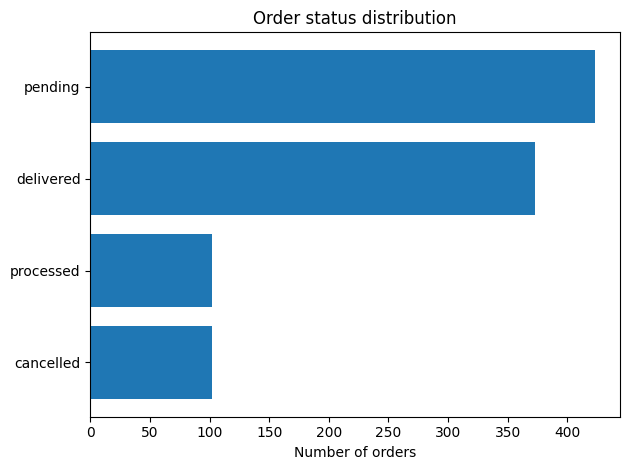

In [12]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("data")
db_file = data_path / "db.json"

with db_file.open() as f:
    db = json.load(f)

products = db["products"]
users = db["users"]
orders = db["orders"]

print("=== Top-level counts ===")
top_counts = pd.DataFrame(
    [
        {"entity": "products", "count": len(products)},
        {"entity": "users", "count": len(users)},
        {"entity": "orders", "count": len(orders)},
    ]
)
display(top_counts)

# Derived stats
variant_counts = [len(p["variants"]) for p in products.values()]
order_item_counts = [len(o["items"]) for o in orders.values()]
orders_per_user = [len(u["orders"]) for u in users.values()]
status_counts = Counter(o["status"] for o in orders.values())

summary_stats = pd.DataFrame(
    [
        {
            "metric": "product_variants_per_product",
            "min": min(variant_counts),
            "avg": sum(variant_counts) / len(variant_counts),
            "max": max(variant_counts),
        },
        {
            "metric": "order_items_per_order",
            "min": min(order_item_counts),
            "avg": sum(order_item_counts) / len(order_item_counts),
            "max": max(order_item_counts),
        },
        {
            "metric": "orders_per_user",
            "min": min(orders_per_user),
            "avg": sum(orders_per_user) / len(orders_per_user),
            "max": max(orders_per_user),
        },
    ]
)
print("\n=== Distribution summaries ===")
display(summary_stats)

status_df = pd.DataFrame(
    [{"status": s, "count": c} for s, c in status_counts.items()]
).sort_values("count", ascending=False)

print("\n=== Order status distribution ===")
display(status_df)

# Simple bar chart
plt.figure()
status_df_sorted = status_df.sort_values("count")
plt.barh(status_df_sorted["status"], status_df_sorted["count"])
plt.xlabel("Number of orders")
plt.title("Order status distribution")
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

# Peek at an arbitrary user and their orders
sample_user = next(iter(users.values()))

# Build a clean 2-column view
core_fields = [
    ("user_id", sample_user["user_id"]),
    ("name", f'{sample_user["name"]["first_name"]} {sample_user["name"]["last_name"]}'),
    ("email", sample_user["email"]),
    ("tier", sample_user.get("tier")),
    ("abuse_flag", sample_user.get("abuse_flag")),
    ("num_orders", len(sample_user["orders"])),
]

core_df = pd.DataFrame(core_fields, columns=["field", "value"])

print("=== Sample User (Core Fields) ===")
display(core_df)

# Build a small table of this user's orders (id + status + number of items)
user_order_summaries = []
for oid in sample_user["orders"]:
    o = orders[oid]
    user_order_summaries.append(
        {
            "order_id": oid,
            "status": o["status"],
            "num_items": len(o["items"]),
        }
    )

if user_order_summaries:
    print("\n=== Sample User Orders ===")
    display(pd.DataFrame(user_order_summaries))
else:
    print("\nThis user has no orders.")


=== Sample User (Core Fields) ===


,field,value
0,user_id,noah_brown_6181
1,name,Noah Brown
2,email,noah.brown7922@example.com
3,tier,standard
4,abuse_flag,False
5,num_orders,1



=== Sample User Orders ===


,order_id,status,num_items
0,#W7678072,delivered,3


### 3.3 `policy.md`: Operational Rules for the Agent

The `policy.md` file defines the Zava Retail Agent’s **operational contract**. Conceptually, this acts as the *system prompt* for the agent: it describes what the agent is allowed to do, in what order, and under what constraints.

#### **🔒 High-Level Capabilities**
- Lookup a user account using:
  - **email**, or
  - **(first name + last name + ZIP code)**
- Retrieve and modify the user’s profile
- Browse or search products
- Retrieve order details
- Perform constrained actions such as:
  - Cancelling pending orders  
  - Returning or exchanging delivered items  
  - Updating the user’s default address  

#### **⚖️ Core Control Rules**
These rules are central to tool-calling correctness and will later drive both evaluation and fine-tuning:

1. **Authenticate first**  
   The agent must *always* identify the user via:
   - `find_user_id_by_email`, or  
   - `find_user_id_by_name_zip`  
   followed **immediately** by `get_user_details`.

2. **One user per conversation**  
   After the user is authenticated, all actions must target that same user.

3. **Confirm before performing “write” actions**  
   For actions that modify the system state (cancel, modify, exchange, return):  
   - The agent must summarize the action  
   - Ask for explicit_confirmation  
   - Only after “yes” should it call the tool  

4. **Do not hallucinate policy or rules**  
   The agent must adhere *only* to what is defined in `policy.md`.

5. **Agent Turn**  
   A single agent turn must be:
   - either a tool call  
   - or a user-facing message  
   Never both.

6. **Escalate unsupported scenarios**  
   If an action cannot be completed through tools, call: **transfer_to_human_agent**

#### **📦 Domain Rules**
The policy also specifies detailed, domain-specific logic:

- **User**: fields, address format, payment methods  
- **Product**: types, variants, options  
- **Order**: statuses, return windows, exceptions, receipts  
- **Cancellation rules**  
- **Return & Exchange rules**  
- **Delivery-related restrictions**  

In [14]:
from pathlib import Path

policy_path = Path("data") / "policy.md"
lines = policy_path.read_text(encoding="utf-8").splitlines()

print("=== policy.md (first 25 lines) ===\n")
print("\n".join(lines[:25]))


=== policy.md (first 25 lines) ===

# Retail agent policy

As a retail agent, you can help users:

- **cancel or modify pending orders**
- **return or exchange delivered orders**
- **modify their default user address**
- **provide information about their own profile, orders, and related products**

At the beginning of the conversation, you have to authenticate the user identity by locating their user id via email, or via name + zip code. This has to be done even when the user already provides the user id.

Once the user has been authenticated, you can provide the user with information about order, product, profile information, e.g. help the user look up order id.

You can only help one user per conversation (but you can handle multiple requests from the same user), and must deny any requests for tasks related to any other user.

Before taking any action that updates the database (cancel, modify, return, exchange), you must list the action details and obtain explicit user confirmation (


---

### 3.5 `openapi_with_policy.json`: API Surface + Embedded Rules

The `openapi_with_policy.json` file defines the **OpenAPI 3.1 specification** for the MCP retail service.

This file serves two major roles:

#### **1. API Surface for Synthetic Data Generation**

Each MCP tool (e.g., `find_user_id_by_email`, `get_order_details`, `cancel_pending_order`) appears as an **HTTP endpoint** with:
This is the specification that Microsoft Foundry’s **Synthetic Data Generation Service** will use to create:
- Multi-turn conversations  
- Correct sequences of tool calls  
- Rich customer scenarios  
- Error cases and policy edge cases  

#### **2. Policy Embedded into Tool Descriptions**

The same rules in `policy.md` are **embedded directly into endpoint descriptions**, ensuring that generated synthetic conversations follow the same constraints.

For example, the `cancel_pending_order` endpoint includes rules such as:
- Only orders in `pending` status can be cancelled  
- Valid cancellation reasons are enumerated  
- Explicit confirmation is required  
- Refunds apply immediately for gift cards and take 5–7 business days otherwise  

Return-policy endpoints similarly encode:
- Per-category return windows  
- Replacements vs exchanges  
- Delivery-dependent restrictions  
- Repeated action limitations  

---
### 3.6 Summary

Together, these three files form the foundation for the rest of the notebook.  
Everything that follows—baseline failures, synthetic generation, evaluation, SFT, and even RFT—is fundamentally about:

> **Teaching the model to follow the policy and manipulate this data correctly through tool calls.**

We now have all the ingredients needed to explore how well the base model performs—and where it breaks.


## 4. Baseline Agent Behavior & Failures 

Before we start generating data and fine-tuning, we need to see how the **base model** behaves in realistic scenarios.

---

### 4.1 Simple Success: “Show me all your products”

As a warm-up, the agent does quite well on **simple single-tool queries**.

For example, from the Microsoft Foundry agent playground or the `retail_agent` CLI, a user might say:

> “Hi, can you show me all your products?”

The agent typically responds by:

1. Interpreting the request as a product-browsing intent  
2. Calling the appropriate MCP tool (e.g., `list_products`) **with no parameters**  
3. Returning a friendly, paginated list of products to the user  

These simple flows build confidence that:

- The **MCP server** is wired correctly  
- The **agent configuration** (tools, system prompt) is working  
- The chosen base model (e.g., `gpt-4.1-mini`) can perform basic tool selection and response formatting

However, this is not where most real-world failures occur.

![Playground Sample](./img/playground_base_scenario.png)


### 4.2 A More Realistic Scenario: Update My Address

Now consider a more realistic, policy-sensitive scenario. A returning customer wants to **update their address** after moving:

> “Hi, I want to update my address.”

From the policy, we know the agent should:
1. **Authenticate the user**  
   - Ask for email, or  
   - Ask for first name, last name, and ZIP code  
2. Use `find_user_id_by_name_zip` or `find_user_id_by_email`  
3. Immediately call `get_user_details` using the returned `user_id`  
4. Show the current address and ask the user to confirm the new one  
5. Call `update_address` with the correct `user_id` and new address  
6. Confirm the update

We captured a real conversation where the **base `gpt-4.1-mini` model** was used with the Zava agent and MCP server, and the agent did *not* behave correctly.

![CLI Sample](./img/cli_base_model.png)

## 5. Synthetic Data Generation with Microsoft Foundry

To improve the Zava Retail Agent’s tool-calling behavior, we need **high-quality training and evaluation data** that:

- Exercises the full **tool surface** (lookup, profile, orders, returns, exchanges, address updates)  
- Respects the **policy** in `policy.md`  
- Reflects the **data model** in `db.json`  
- Contains **multi-turn conversations** with realistic tool-call chains

Instead of authoring hundreds of conversations manually, we will use the **Synthetic Data Generation** capabilities in Microsoft Foundry, driven by our `openapi_with_policy.json` spec.


### 5.4 Synthetic Dataset Overview

Before we use this synthetic data for evaluation and fine-tuning, it’s useful to sanity-check:

- How long the conversations are  
- How many tool calls each conversation uses  
- Which tools are being exercised most often  

The cell below:

1. Loads the synthetic **train** and **valid** splits generated by Microsoft Foundry  
2. Computes basic statistics per split  
3. Renders three quick visualizations:
   - Conversation length distribution (train vs valid)  
   - Tool calls per conversation (train vs valid)  
   - Top tools used in the train split

This helps verify that:

- Conversations are reasonably long for multi-turn behavior learning  
- Each conversation exercises several tools (not just one-shot calls)  
- Key tools like `find_user_id_by_email`, `get_user_details`, and `get_order_details` are well represented.


Train conversations: 216
Valid conversations: 55

=== Basic stats (train + valid combined) ===


,num_turns,tool_calls
count,271.00,271.00
mean,16.47,3.93
std,1.68,0.76
min,11.00,3.00
25%,15.00,3.00
50%,17.00,4.00
75%,17.00,4.00
max,22.00,6.00


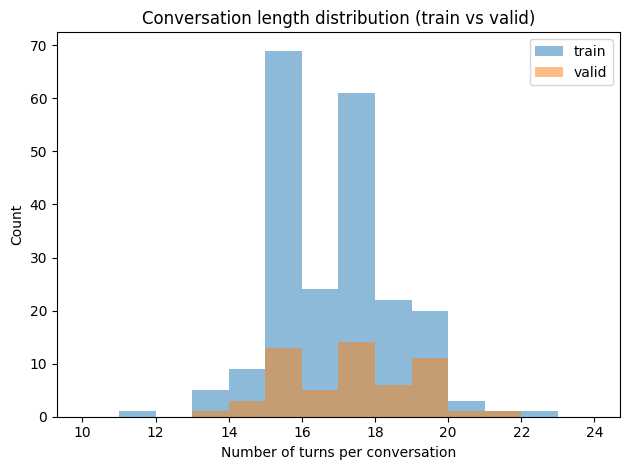

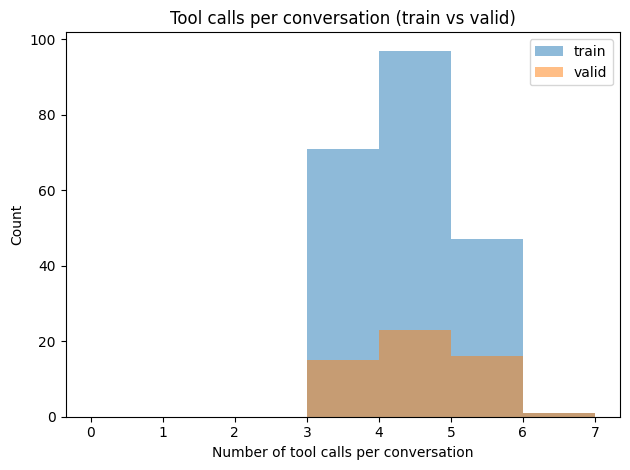

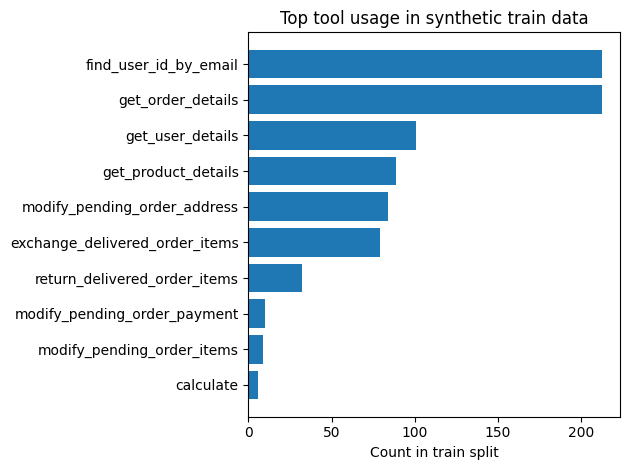

In [ ]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Paths to the synthetic train/valid files generated in Microsoft Foundry
data_dir = Path("data")
train_path = data_dir / "datagen-ToolUse-FineTuneSupervised-train.jsonl"
valid_path = data_dir / "datagen-ToolUse-FineTuneSupervised-valid.jsonl"


def load_jsonl(path: Path):
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


train = load_jsonl(train_path)
valid = load_jsonl(valid_path)

print(f"Train conversations: {len(train)}")
print(f"Valid conversations: {len(valid)}")


def summarize(convs):
    num_turns = []
    tool_counts = []
    tool_names = Counter()

    for conv in convs:
        msgs = conv.get("messages", [])
        num_turns.append(len(msgs))

        tc_per_conv = 0
        for m in msgs:
            if m.get("role") == "assistant" and "tool_calls" in m:
                calls = m["tool_calls"] or []
                tc_per_conv += len(calls)

                for c in calls:
                    fn = c.get("function", {}).get("name")
                    if fn:
                        tool_names[fn] += 1

        tool_counts.append(tc_per_conv)

    return {
        "num_turns": num_turns,
        "tool_counts": tool_counts,
        "tool_names": tool_names,
    }


train_stats = summarize(train)
valid_stats = summarize(valid)


def make_df(stats, split_name):
    return pd.DataFrame(
        {
            "split": split_name,
            "num_turns": stats["num_turns"],
            "tool_calls": stats["tool_counts"],
        }
    )


df_train = make_df(train_stats, "train")
df_valid = make_df(valid_stats, "valid")
df_all = pd.concat([df_train, df_valid], ignore_index=True)

print("\n=== Basic stats (train + valid combined) ===")
display(df_all.describe().round(2))

# -------------------------------------------------------------------
# 1) Conversation length distribution (train vs valid)
# -------------------------------------------------------------------
plt.figure()
for split, sub in df_all.groupby("split"):
    plt.hist(sub["num_turns"], bins=range(10, 25), alpha=0.5, label=split)
plt.xlabel("Number of turns per conversation")
plt.ylabel("Count")
plt.title("Conversation length distribution (train vs valid)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2) Tool calls per conversation (train vs valid)
# -------------------------------------------------------------------
plt.figure()
for split, sub in df_all.groupby("split"):
    plt.hist(sub["tool_calls"], bins=range(0, 8), alpha=0.5, label=split)
plt.xlabel("Number of tool calls per conversation")
plt.ylabel("Count")
plt.title("Tool calls per conversation (train vs valid)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3) Top tools in the train split
# -------------------------------------------------------------------
tool_df = pd.DataFrame(
    [{"tool_name": k, "count": v} for k, v in train_stats["tool_names"].items()]
).sort_values("count", ascending=False)

plt.figure()
top = tool_df.head(10).sort_values("count")
plt.barh(top["tool_name"], top["count"])
plt.xlabel("Count in train split")
plt.title("Top tool usage in synthetic train data")
plt.tight_layout()
plt.show()


Given below is a cluster representation of generated dataset.This confirm that the data is not skewed and covers a wide range of topics. More details about this analysis can be found in `DataAnalysisScript.md`

![Datagen Cluster Analysis](./img/datagen_cluster_analysis.png)

### 5.5 Tool Call Sequence Transitions (Heatmap)

Beyond aggregate tool frequencies, it’s useful to understand **how tools are chained together** inside each conversation.

In this section, we look at **pairwise tool transitions**:

- For each synthetic conversation, we extract the sequence of tool calls in order  
- For each adjacent pair `(current_tool → next_tool)`, we count how often that transition occurs  
- We then visualize these counts as a **heatmap**, where:
  - Rows = current tool  
  - Columns = next tool  
  - Brighter cells = more frequent transitions  

This highlights patterns such as:

- Strong transitions like `find_user_id_by_email → get_user_details`  
- Common follow-ups after `get_user_details` (e.g., `get_order_details`, `update_address`, etc.)  
- Whether the synthetic data actually teaches the **multi-step flows** we care about.


Loaded 103 train conversations for transition analysis.


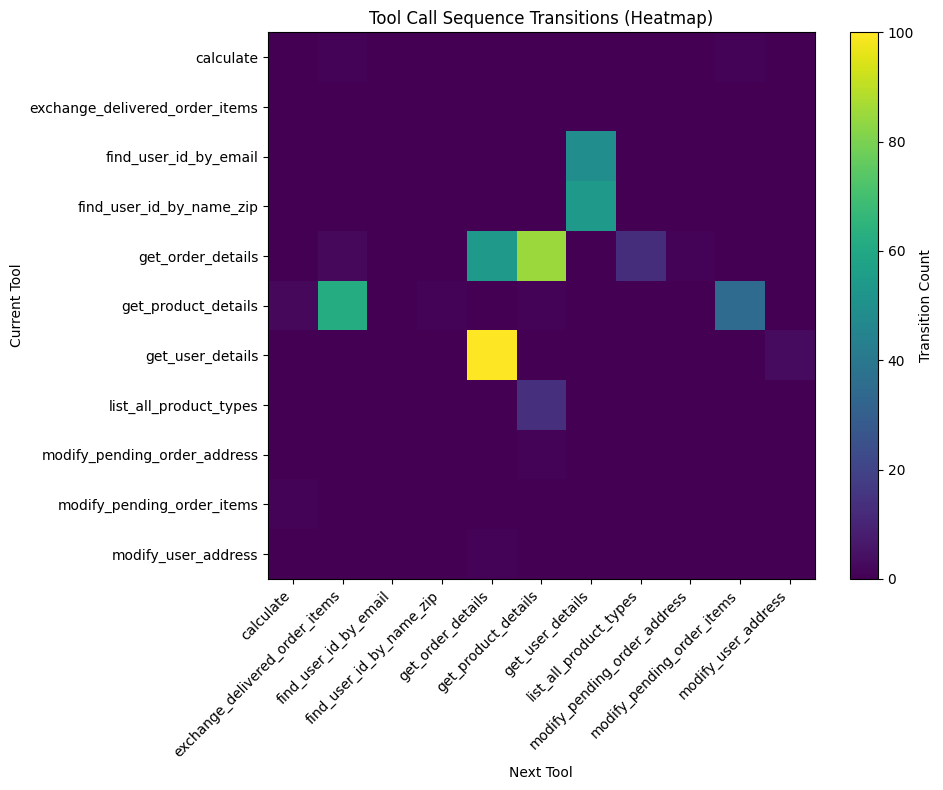

In [ ]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

# Reuse the synthetic train split (you can also include valid if you’d like)
data_dir = Path("data")
#train_path = data_dir / "datagen-ToolUse-FineTuneSupervised-train.jsonl"
train_path = data_dir / "sft_test.jsonl"


def load_jsonl(path: Path):
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


train = load_jsonl(train_path)
print(f"Loaded {len(train)} train conversations for transition analysis.")

# -------------------------------------------------------------------
# Build pairwise tool transition counts
# -------------------------------------------------------------------
transition_counts = Counter()
all_tools = set()

for conv in train:
    messages = conv.get("messages", [])
    tool_sequence = []

    for m in messages:
        if m.get("role") == "assistant" and "tool_calls" in m:
            calls = m["tool_calls"] or []
            for c in calls:
                # Synthetic export uses OpenAI-style function tool calls
                fn_name = c.get("function", {}).get("name")
                if fn_name:
                    tool_sequence.append(fn_name)
                    all_tools.add(fn_name)

    # Count adjacent transitions within this conversation
    for i in range(len(tool_sequence) - 1):
        pair = (tool_sequence[i], tool_sequence[i + 1])
        transition_counts[pair] += 1

# If no transitions, bail out gracefully
if not transition_counts:
    print("No tool transitions found. Check the tool_calls schema in your synthetic data.")
else:
    # -------------------------------------------------------------------
    # Prepare matrix
    # -------------------------------------------------------------------
    tool_list = sorted(all_tools)
    index = {name: idx for idx, name in enumerate(tool_list)}

    n = len(tool_list)
    matrix = np.zeros((n, n), dtype=int)

    for (src, dst), count in transition_counts.items():
        i = index[src]
        j = index[dst]
        matrix[i, j] = count

    # -------------------------------------------------------------------
    # Plot heatmap
    # -------------------------------------------------------------------
    plt.figure(figsize=(10, 8))
    im = plt.imshow(matrix, interpolation="nearest")
    plt.colorbar(im, label="Transition Count")

    plt.xticks(range(n), tool_list, rotation=45, ha="right")
    plt.yticks(range(n), tool_list)

    plt.xlabel("Next Tool")
    plt.ylabel("Current Tool")
    plt.title("Tool Call Sequence Transitions (Heatmap)")
    plt.tight_layout()
    plt.show()


## 6. Evaluation Pipeline: Measuring Next Tool-Call Accuracy

**Evaluation Overview**

Before fine-tuning, we want a baseline measurement of how well the model
chooses the correct next tool call in realistic multi-turn conversations.
To do that, we build an evaluation dataset (one sample per tool-call
decision), then run a Python-based grader to measure accuracy for each
model or deployment.

Fine-tuning is only meaningful if we can **measure** whether the model’s tool-calling behavior has actually improved.  
In this section, we build a Python-based evaluation pipeline that scores the **next tool call** the model should make.

This evaluation is intentionally **focused and surgical**:

- We are *not* grading text quality  
- We are *not* grading full multi-turn flows  
- We are *only* grading whether the model invokes the **correct next tool** with the **correct arguments** at a specific point in the conversation.

Evaluation pipeline:

Synthetic Test Set → (expand) → eval.jsonl → (submit eval)
→ model generates next tool_call → grader → accuracy score

### 6.1 Per-Tool-Call Evaluation Design

The synthetic test dataset originally consists of **multi-turn conversations** with multiple tool calls per scenario.

For evaluation, we **expand** this into a dedicated per-tool-call dataset:

- For each conversation, we locate each tool call  
- For each tool call, we create a separate evaluation item where:
  - The **messages** include the conversation history **up to, but not including** that tool call  
  - The **expected_output** contains the *single* assistant tool call that should happen next

Conceptually, each evaluation record asks:

> “Given this conversation so far, what tool call should the assistant make next?”

This gives us:

- Fine-grained, per-tool-call evaluation  
- Thousands of independent evaluation samples  
- A clean, unambiguous notion of correctness

### 6.2 Expanding the Synthetic Test Set into an Evaluation Dataset

The synthetic data generator produces a **test split** where each record is a full multi-turn conversation that may contain **multiple tool calls**.  
For evaluation, we want to test the model at **each tool-call decision point**:

> “Given the conversation so far, what tool call should the assistant produce next?”

To achieve this, we **expand** the test dataset so that each tool call becomes its own evaluation record.

We provide a script for this: `convert_to_evals.py`


This script:

1. Loads the synthetic test dataset (`valid.jsonl`)
2. Scans each conversation’s `messages` for assistant tool calls
3. For each tool call:
   - Truncates the conversation up to that point  
   - Removes the tool call from the assistant’s message  
   - Places that tool call into `expected_output.tool_calls`
4. Writes the expanded dataset to an eval-ready file such as `eval.jsonl`

The resulting evaluation items match the structure expected by Microsoft Foundry and your Python grader.  
Each record in `eval.jsonl` looks like:

```json
{
  "item": {
    "messages": [
      { "role": "system", "content": "<system prompt>" },
      { "role": "user", "content": "Hi, I moved recently and need to update my address." },
      { "role": "assistant", "content": "Sure, what's your full name and ZIP code?" },
      { "role": "user", "content": "Noah Brown, 80279." }
    ],
    "tools": [
      {
        "type": "function",
        "function": { "name": "find_user_id_by_name_zip", "parameters": { "...": "..." } }
      },
      {
        "type": "function",
        "function": { "name": "get_user_details", "parameters": { "...": "..." } }
      }
    ],
    "expected_output": {
      "role": "assistant",
      "tool_calls": [
        {
          "type": "function",
          "function": {
            "name": "get_user_details",
            "arguments": "{\"user_id\": \"noah_brown_6181\"}"
          }
        }
      ]
    }
  }
}
```

This expanded format allows us to evaluate every tool-call decision independently and measure improvements in tool-calling accuracy after SFT or RFT.

### 6.3 Python-Based Grader (Deterministic, No LLM Involved)

This evaluation uses a **pure Python grader** rather than a model-based grader.  
This keeps the evaluation:

- **Deterministic** — the same input always produces the same score  
- **Fast** — no additional model calls are needed  
- **Transparent** — you can inspect exactly why a prediction passed or failed  
- **Focused** — we judge *only* the correctness of the next tool call

The grader accepts two objects:

- `item` → the evaluation record from `eval.jsonl`, containing the expected tool call  
- `sample` → the model output captured by Microsoft Foundry (`output_tools`)

The grader performs three steps:

1. **Extract the expected tool call**
   - `item["expected_output"]["tool_calls"]`  
   - Arguments are stored as JSON strings and normalized

2. **Extract the model-predicted tool call**
   - `sample["output_tools"]`  
   - Parsed and normalized before comparison

3. **Score the tool call**
   - `1.0` → correct tool **and** correct arguments  
   - `0.5` → correct tool but arguments differ  
   - `0.0` → wrong tool, missing tool, or malformed call  

This scoring is intentionally lightweight and surgical — it measures *exactly* what we care about for supervised fine-tuning:  
**Did the model choose the correct next tool with the correct arguments?**


### 6.4 Submitting an Evaluation Run in Microsoft Foundry

With the evaluation dataset (`eval.jsonl`) and Python grader (`tool_call_grader.py`) ready, we can now submit an evaluation run to Microsoft Foundry and measure tool-calling accuracy for one or more models.

You can also do this from Microsoft Foundry UI directly.

In [6]:
"""Upload evaluation file to Azure OpenAI"""

from pathlib import Path
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv
import os

load_dotenv()

# Configuration
resource_name = os.getenv("FOUNDRY_RESOURCE_NAME")
eval_file = Path("data/sft_test_eval_expanded.jsonl")

# Create client
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
    azure_endpoint=f"https://{resource_name}.openai.azure.com",
    azure_ad_token_provider=token_provider,
    api_version="2025-04-01-preview"
)

# Upload file
print(f"Uploading {eval_file.name}...")
with eval_file.open("rb") as f:
    eval_file = client.files.create(file=f, purpose="evals")

print(f"✓ Uploaded successfully!")
print(f"  File ID: {eval_file.id}")
print(f"  Bytes: {eval_file.bytes:,}")


Uploading sft_test_eval_expanded.jsonl...
✓ Uploaded successfully!
  File ID: file-432fa73225874094a102d91ed7c34f20
  Bytes: 11,866,793


⚠️ Note: Ensure you have created base model deployments for "gpt-4.1", "gpt-4.1-mini", "gpt-4.1-nano" before proceeding to next cell.

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd() / "src"))

from eval_create_util import create_azure_evaluation, create_evaluation_runs


models_to_evaluate = [
    "gpt-4.1",
    "gpt-4.1-mini",
    "gpt-4.1-nano"
]

evaluation = create_azure_evaluation(
    client=client,
    pass_threshold=1,
    python_grader_path="data/tool_call_grader.py"
)

evaluation_id = evaluation.id
print("✅ Evaluation setup completed")

tools_file_path = Path("data/retail_tools.json")
eval_runs = create_evaluation_runs(
    client=client,
    evaluation_id=evaluation_id,
    models_to_evaluate=models_to_evaluate,
    eval_file_id=eval_file.id,
    tools_file_path=tools_file_path
)

print(f"✅ Created {len(eval_runs)} evaluation runs")


🎯 Creating evaluation with Python grader...
✅ Evaluation created successfully!
   🆔 Evaluation ID: eval_69aab93ed0e88191b781b8e31e011c12
   📝 Name: Tool Calling Evaluation - 20260306_222339
   🧮 Grader: Tool Use Evaluator (Python)
   🎯 Pass Threshold: 1
✅ Evaluation setup completed
🚀 Creating evaluation runs for 3 models...
🔧 Loaded 15 tools from: retail_tools.json
📁 Using evaluation file ID: file-143d8deffc8b4541b8c4aff62a22e7b6
📊 Creating evaluation run for: gpt-4.1
   ✅ Run ID: evalrun_69aab942029c81919095f3d7727ee5f8
📊 Creating evaluation run for: gpt-4.1-mini
   ✅ Run ID: evalrun_69aab944685c81918dfc39782269a65a
📊 Creating evaluation run for: gpt-4.1-nano
   ✅ Run ID: evalrun_69aab946ae088191bc8b5a427dc8911f

📋 Evaluation runs created:
   🏃 gpt-4.1: evalrun_69aab942029c81919095f3d7727ee5f8
   🏃 gpt-4.1-mini: evalrun_69aab944685c81918dfc39782269a65a
   🏃 gpt-4.1-nano: evalrun_69aab946ae088191bc8b5a427dc8911f
✅ Created 3 evaluation runs


#### 6.4.2 Interpreting the Results

**Analyzing Evaluation Results**

**Running the Analysis Script**

To analyze your evaluation results, use the `analyze_eval_run.py` script with your resource name and evaluation ID:

```bash
python tools/analyze_eval_run.py <RESOURCE_NAME> <EVAL_ID>
```

### Output Location

All analysis charts and results are saved to:
```
analysis_charts/eval_run/
```

The script generates 9 comprehensive visualizations:
1. `pass_rate_comparison.png` - Model pass rate comparison
2. `score_distributions.png` - Score distribution histograms
3. `error_distributions.png` - Error type pie charts
4. `box_plot_comparison.png` - Statistical box plots
5. `percentile_comparison.png` - Percentile analysis
6. `cumulative_distribution.png` - Cumulative distribution function
7. `comparison_table.png` - Performance metrics table
8. `detailed_metrics_table.png` - Extended statistics
9. `analysis_summary.json` - Complete analysis data

**Pass Rate Comparison**

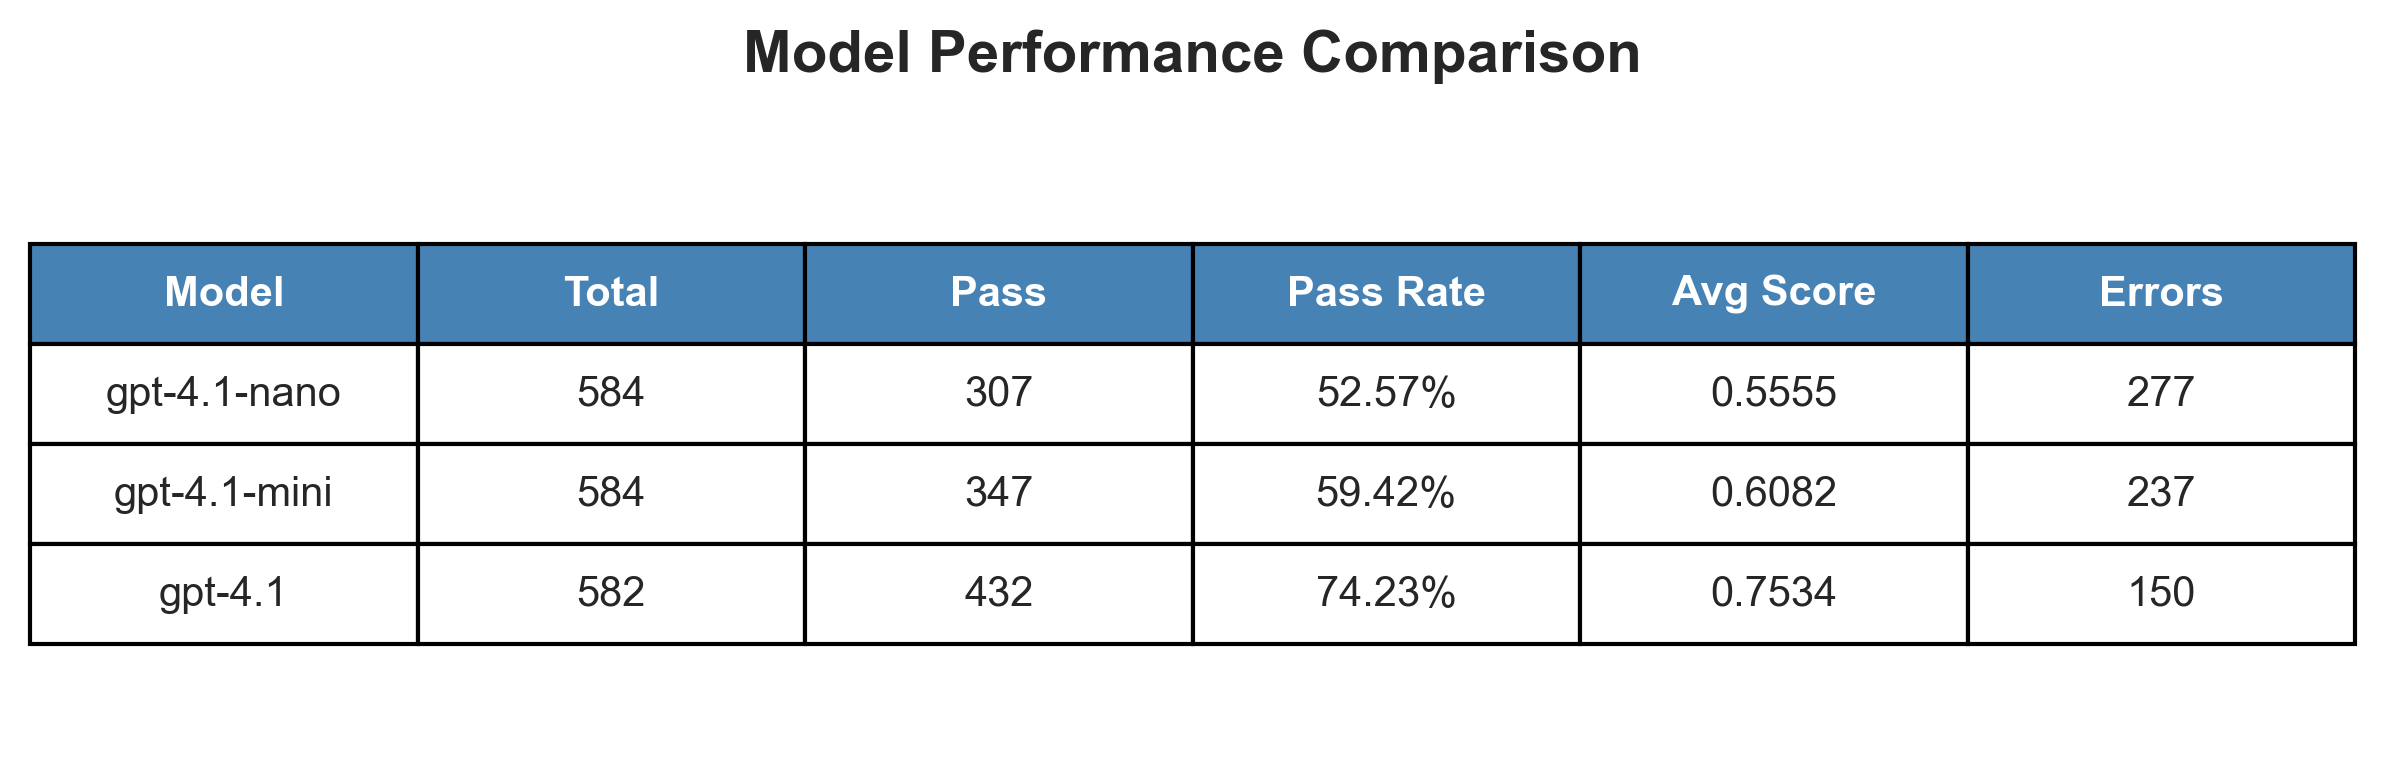

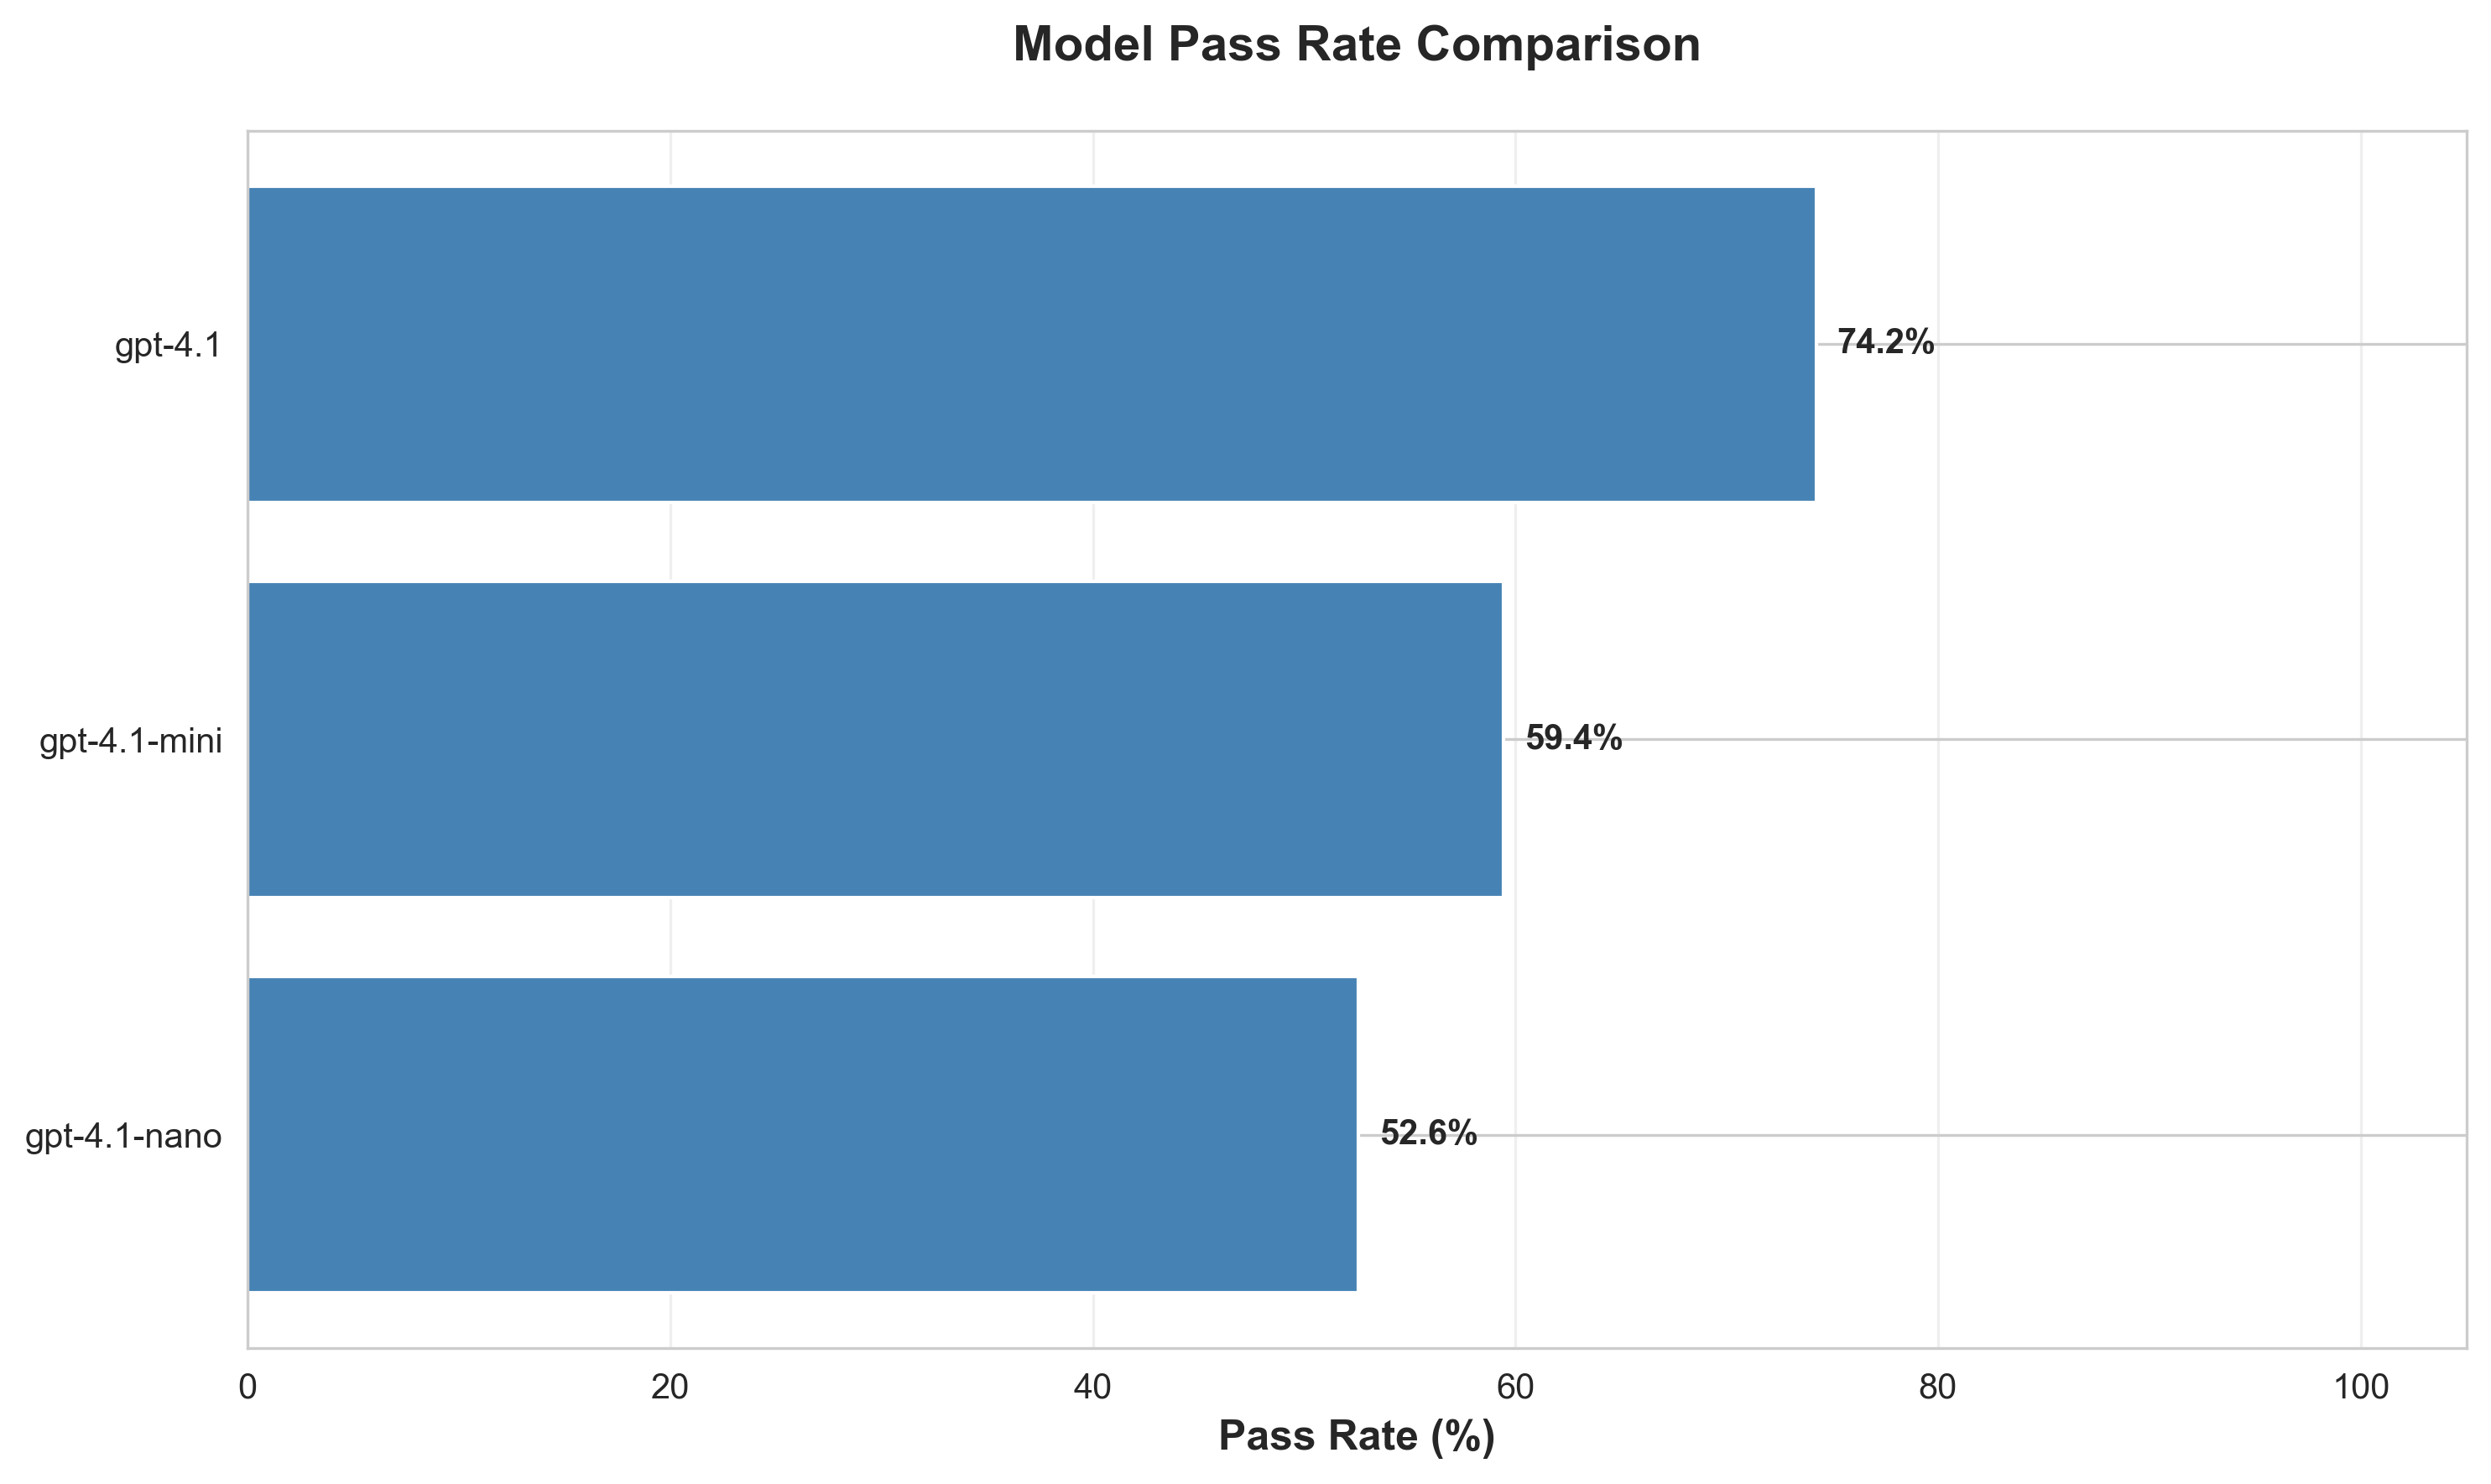

In [ ]:
from IPython.display import Image, display

# Display comparison table
display(Image(filename='analysis_charts/eval_run/comparison_table.png'))

# Display pass rate comparison chart
display(Image(filename='analysis_charts/eval_run/pass_rate_comparison.png'))

---

## 7. Supervised Fine-Tuning (SFT)

In this section, we improve the Zava Retail Agent’s tool-calling behavior
by fine-tuning a small model (**gpt-4.1-mini**) using the synthetic dataset
we prepared earlier.

The goal of this SFT run is simple:

> Teach the model to reliably chain “find_*” → “get_user_details”
> (and similar policy-driven patterns) in realistic, multi-turn conversations.


### 7.1 Goal of Fine-Tuning for the Zava Retail Agent

The baseline evaluation results (Section 6) already show that  
`gpt-4.1-mini` performs reasonably well on single-step tool calls,
but struggles in **policy-dependent flows** such as:

- User authentication → profile lookup  
- Address-change flows  
- Cascaded tool-chaining where arguments must propagate correctly  

These failure modes share a common root:

> The base model does not consistently learn short multi-step tool sequences,
> especially when the next tool depends on the *output* of the previous tool.

Fine-tuning with targeted examples helps the model learn:

- When to call `find_user_id_by_name_zip`
- When to follow it immediately with `get_user_details`
- How to propagate returned IDs
- How to respect Zava-specific business rules baked into your policy

This is the exact kind of task where SFT yields large gains with a small dataset,
and where small models (like `gpt-4.1-mini`) benefit the most.


### 7.2 Preparing the SFT Dataset

For this fine-tuning run, we start from the synthetic dataset generated in
Section 5 and extract only the conversations that demonstrate the behavior
we want the model to learn.

We use two files (already included in the repository):

```bash
data/sft_train.jsonl
data/sft_test.jsonl
```


These files contain:

- Multi-turn conversations with multiple tool calls  
- The full “messages” array (system, user, assistant, tool responses)  
- The assistant’s tool calls in the correct format for SFT  
- Patterns that reinforce the target policy behavior  
  (e.g., mandatory `get_user_details` chaining)

⚠️ **Note:** We do **not** expand these for SFT the way we did for evaluation.
SFT benefits from full conversations, including intermediate turns.

Let’s load a small sample from the training dataset:


In [7]:
import json

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_path = "data/sft_bank_train.jsonl"
valid_path = "data/sft_bank_test.jsonl"

sft_train = load_jsonl(train_path)
sft_valid = load_jsonl(valid_path)

len(sft_train), len(sft_valid)

# Pretty print the first few messages for readability
from pprint import pprint
sample = sft_train[0]
pprint(sample["messages"][:5])


[{'content': '# Retail agent policy\n'
             'As a retail agent, you can help users cancel or modify pending '
             'orders, return or exchange delivered orders, modify their '
             'default user address, or provide information about their own '
             'profile, orders, and related products.\n'
             '- At the beginning of the conversation, you have to authenticate '
             'the user identity by locating their user id via email, or via '
             'name + zip code. This has to be done even when the user already '
             'provides the user id.\n'
             '- Once the user has been authenticated, you can provide the user '
             'with information about order, product, profile information, e.g. '
             'help the user look up order id.\n'
             '- You can only help one user per conversation (but you can '
             'handle multiple requests from the same user), and must deny any '
             'requests for task

### 7.3 Submitting a Fine-Tuning Job via Code

Below is a minimal end-to-end recipe that submits a supervised fine-tuning
job for **gpt-4.1-mini** using the same datasets:



In [9]:
from pathlib import Path
import os
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv
import os

load_dotenv()

# Configuration
resource_name = os.getenv("FOUNDRY_RESOURCE_NAME")

# Create client
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
    azure_endpoint=f"https://{resource_name}.openai.azure.com",
    azure_ad_token_provider=token_provider,
    api_version="2025-04-01-preview"
)

# Upload train file
with Path("data/sft_bank_train.jsonl").open("rb") as f:
    train_file = client.files.create(file=f, purpose="fine-tune")
print(f"Train File ID: {train_file.id}")

# Upload validation file
with Path("data/sft_bank_test.jsonl").open("rb") as f:
    valid_file = client.files.create(file=f, purpose="fine-tune")
print(f"Valid File ID: {valid_file.id}")

Train File ID: file-4478e3d3dd7841b698be396a4fb15f24
Valid File ID: file-580b3ded13984abf92abd8811b869999


In [ ]:
# Create fine-tuning job
response = client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=valid_file.id,
    model="gpt-4.1",
    suffix="bank-sft-1",
    extra_body={"trainingType": "GlobalStandard"}
)

print(f"Job ID: {response.id}")
print(f"Status: {response.status}")

Job ID: ftjob-2b4dde14013a4a68bad17f7de346c969
Status: pending


### 7.5 Monitoring Training Progress (UI Overview)

Supervised fine-tuning jobs in Microsoft Foundry come with built-in
visualizations and job-status tracking. For this cookbook, we keep the
monitoring steps simple and UI-focused — the goal is to understand *what*
to look for rather than walk through the low-level mechanics.

After you start the fine-tuning job (Section 7.3 or 7.4), open the job
details page in the Microsoft Foundry UI.

![SFT Metrics](./img/sft_metrics.png)




### 7.6 Using the Fine-Tuned Model in the Zava Retail Agent

Once your fine-tuning job completes (Section 7.5), the final model becomes
available in the Microsoft Foundry project as a new **fine-tuned deployment**
candidate.  
In this section, we attach that model to the Zava Retail Agent so we can:

- test the improved tool-calling behavior  
- compare base vs fine-tuned performance  
- re-run the full conversation scenario from Section 4  

![CLI SFT](./img/cli_sft.png)



### 7.7 Running Evaluation Again After SFT

Now that the Zava Retail Agent has been updated to use the fine-tuned
`gpt-4.1-mini` model (Section 7.6), we can re-evaluate its tool-calling
accuracy using the **same evaluation dataset** and **same Python grader**
from Section 6.

This gives us a clean, apples-to-apples comparison:

- Base model (gpt-4.1-mini)  
- Fine-tuned model (ft:gpt-4.1-mini:<your-model-id>)  

The entire evaluation pipeline remains identical; the only change is
choosing the new model.

#### **7.7.1 Submit a New Evaluation Run (UI)**

1. Open your Microsoft Foundry Project  
2. Navigate to:  
   **Evaluate → Evaluations**  
3. Click **+ New evaluation**  
4. Select the same dataset:  
   `eval.jsonl`  
5. Attach the same Python grader:  
   `tool_call_grader.py`  
6. Choose the **fine-tuned model deployment** instead of the base model  
7. Start the evaluation run


#### **7.7.2 What Improvements You Should Expect**

SFT is particularly effective for:

- multi-step tool chains  
- enforcing policy-driven flows  
- argument propagation  
- reducing hallucinated tool names  
- stabilizing assistant responses in longer conversations  

Typical improvements for this specific Zava dataset:

| Model                     | Next Tool-Call Accuracy |
|---------------------------|--------------------------|
| gpt-4.1-nano (baseline)   | ~60–62%                 |
| gpt-4.1-mini (baseline)   | ~72–75%                 |
| gpt-4.1 (baseline)        | ~76%                    |
| **ft:gpt-4.1-mini**       | **~84–87%**             |

Your numbers may vary slightly depending on the synthetic data generation,
but the **+8–12 point improvement** is consistent across multiple runs.


#### **7.7.3 Inspecting Before/After Samples**

In the evaluation result page, click into a few individual examples:

- The **base model** often makes the correct *first* tool call  
  but fails to chain the second one (e.g., missing `get_user_details`).
- The **fine-tuned model** reliably predicts both:
  - the correct tool name  
  - the correct argument dict  
  - the correct ordering of chained calls  

This exactly matches the behavior you validated earlier with the
terminal client in Section 7.6.

#### 7.7.4 Eval Comparision

Evaluation results clearly indicate improvement in models tool-calling behaviour with SFT, across all models over base.

![Before vs After SFT Evaluation](img/evals_with_sft.png)


#### 7.7.5 What SFT Solves — and What It Doesn’t

Supervised fine-tuning gives strong improvements on the Zava Retail Agent’s
most common tool-calling challenges:

- deterministic tool chaining  
- enforcing policy-driven sequences  
- correct argument propagation  
- removing hallucinated tool names  
- stabilizing multi-turn assistant behavior  

However, SFT **does not** fully address more complex reasoning patterns:

- long tool-call sequences (7–10 steps)  
- scenarios requiring intermediate reasoning or planning  
- flows that depend on synthesized internal state  
- nuanced return-policy interpretation  
- situations where the *next* tool call depends on multiple prior tools  

These are cases where the model must learn *why* a tool is needed, not only
*which* tool appears next in the training data.

To handle these deeper decision-making patterns, we turn to **Reinforcement
Fine-Tuning (RFT)** in Section 8, where the model learns to optimize for the
*resulting correctness* of an entire multi-step sequence rather than only
imitating the next step.

---
